# Minecraft Mob Detection

Ноутбук для EDA, подготовки данных, обучения FCOS и YOLOv8s, инференса и сравнения метрик.


## 1. Инициализация

In [1]:
import os
from pathlib import Path

LOCAL_CACHE = Path('.cache_runtime')
LOCAL_CACHE.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(LOCAL_CACHE / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(LOCAL_CACHE))

import matplotlib.pyplot as plt
import pandas as pd

from project_tools import (
    MINECRAFT_CLASSES,
    build_fcos_config_path,
    build_yolo_data_yaml,
    coco_annotation_summary,
    compare_model_metrics,
    draw_coco_sample,
    plot_class_distribution,
    prepare_yolo_labels,
    run_fcos_image_inference,
    run_fcos_test_evaluation,
    run_fcos_training,
    run_yolo_image_inference,
    run_yolo_training,
    run_yolo_validation,
    save_metrics_comparison,
    validate_coco_annotations,
)

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'minecraft'
ANNOTATIONS_ROOT = DATASET_ROOT / 'annotations'
ARTIFACTS_ROOT = PROJECT_ROOT / 'artifacts'
FCOS_ARTIFACTS = ARTIFACTS_ROOT / 'fcos'
YOLO_ARTIFACTS = ARTIFACTS_ROOT / 'yolo'
INFERENCE_ROOT = ARTIFACTS_ROOT / 'inference'
VIDEOS_ROOT = ARTIFACTS_ROOT / 'videos'
METRICS_ROOT = ARTIFACTS_ROOT / 'metrics'

SMOKE_RUN = False

RUN_FCOS_TRAINING = True
RUN_YOLO_TRAINING = True

PROJECT_ROOT, DATASET_ROOT

(PosixPath('/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection'),
 PosixPath('/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/datasets/minecraft'))

## 2. Проверка структуры датасета

In [2]:
validation_reports = {}
for split in ['train', 'val', 'test']:
    report = validate_coco_annotations(
        ANNOTATIONS_ROOT / f'{split}_annotations.json',
        DATASET_ROOT / split,
    )
    validation_reports[split] = report
    print(split, report)

validation_reports

train {'images_in_json': 2307, 'annotations_in_json': 4029, 'categories_in_json': 18, 'annotations_without_images': [], 'missing_on_disk': [], 'extra_on_disk': ['00_plains_0_0_jpg.rf.d5c1e5126176626ad42aa52af5ef9c3a.txt', '00_plains_0_21_jpg.rf.cd39932ef9dc57bc4f97edc39524044b.txt', '00_plains_0_47_jpg.rf.900729e0e8c26e44e019ebd29d8afe52.txt', '01_plains_1_22_jpg.rf.8508e87001ceb548ab1bd3d4a1356b93.txt', '01_plains_1_2_jpg.rf.91fe49f9324892fa0367332fb0447946.txt', '01_plains_1_55_jpg.rf.220add212e92e60aeb1b7e0f417d6bb4.txt', '01_plains_1_66_jpg.rf.0a23b5b86b0a50e0dd6c08e7cde1ff1c.txt', '02_savanna_0_19_jpg.rf.283914d75c9387a3a9e5a5eabcde556a.txt', '02_savanna_0_31_jpg.rf.8747e8803bad69c80ae5ed6acec0607b.txt', '02_savanna_0_47_jpg.rf.590e763a5b71d0ed8f56d22c945566da.txt', '02_savanna_0_5_jpg.rf.2be6d3d5f40becfb01a999d61245f7f7.txt', '03_savanna_1_17_jpg.rf.1a132e45ec3415633f959c691a0b3af7.txt', '03_savanna_1_59_jpg.rf.cd394c27e289be7c031233120bc4bb58.txt', '03_savanna_1_6_jpg.rf.c451b6f

{'train': {'images_in_json': 2307,
  'annotations_in_json': 4029,
  'categories_in_json': 18,
  'annotations_without_images': [],
  'missing_on_disk': [],
  'extra_on_disk': ['00_plains_0_0_jpg.rf.d5c1e5126176626ad42aa52af5ef9c3a.txt',
   '00_plains_0_21_jpg.rf.cd39932ef9dc57bc4f97edc39524044b.txt',
   '00_plains_0_47_jpg.rf.900729e0e8c26e44e019ebd29d8afe52.txt',
   '01_plains_1_22_jpg.rf.8508e87001ceb548ab1bd3d4a1356b93.txt',
   '01_plains_1_2_jpg.rf.91fe49f9324892fa0367332fb0447946.txt',
   '01_plains_1_55_jpg.rf.220add212e92e60aeb1b7e0f417d6bb4.txt',
   '01_plains_1_66_jpg.rf.0a23b5b86b0a50e0dd6c08e7cde1ff1c.txt',
   '02_savanna_0_19_jpg.rf.283914d75c9387a3a9e5a5eabcde556a.txt',
   '02_savanna_0_31_jpg.rf.8747e8803bad69c80ae5ed6acec0607b.txt',
   '02_savanna_0_47_jpg.rf.590e763a5b71d0ed8f56d22c945566da.txt',
   '02_savanna_0_5_jpg.rf.2be6d3d5f40becfb01a999d61245f7f7.txt',
   '03_savanna_1_17_jpg.rf.1a132e45ec3415633f959c691a0b3af7.txt',
   '03_savanna_1_59_jpg.rf.cd394c27e289be7c031

In [3]:
train_summary = coco_annotation_summary(ANNOTATIONS_ROOT / 'train_annotations.json')
pd.Series({
    'images': train_summary['images'],
    'annotations': train_summary['annotations'],
    'categories_in_json': len(train_summary['categories']),
    'target_classes': len(MINECRAFT_CLASSES),
})

images                2307
annotations           4029
categories_in_json      18
target_classes          17
dtype: int64

## 3. EDA

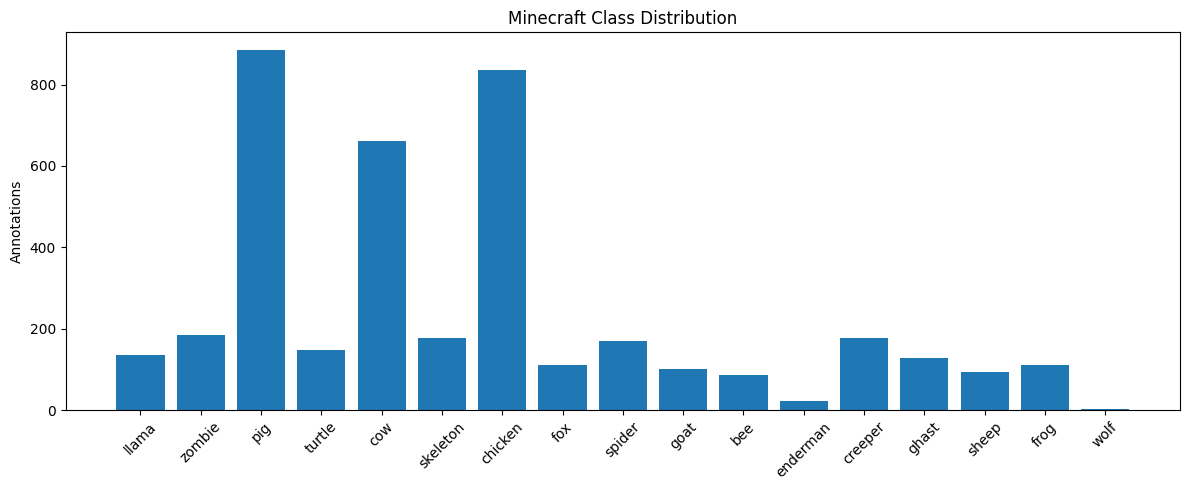

pig         884
chicken     835
cow         661
zombie      184
skeleton    177
creeper     177
spider      170
turtle      149
llama       135
ghast       127
fox         111
frog        111
goat        102
sheep        94
bee          86
enderman     22
wolf          4
dtype: int64

In [4]:
fig, ax, counts = plot_class_distribution(ANNOTATIONS_ROOT / 'train_annotations.json')
plt.show()
pd.Series(counts).sort_values(ascending=False)

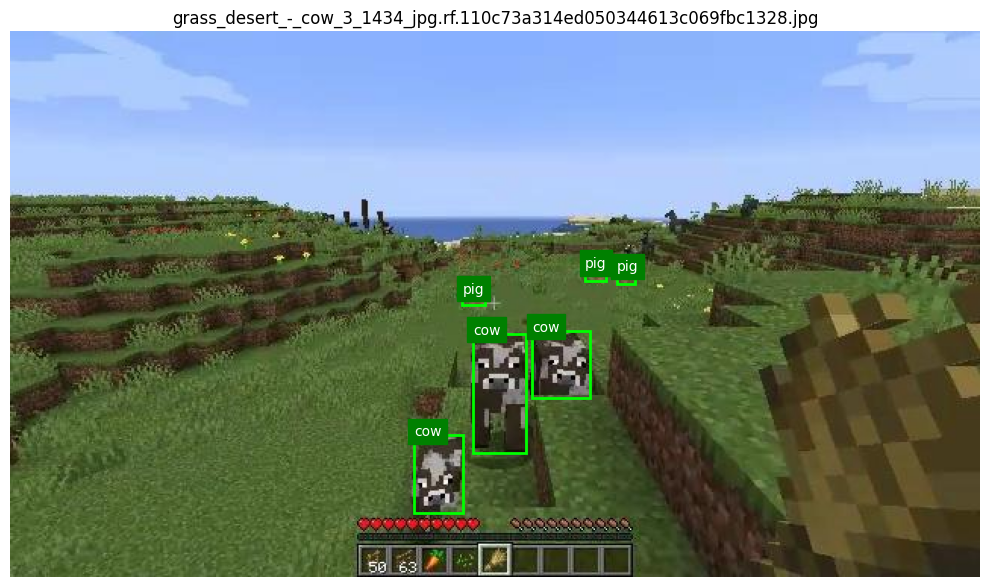

({'id': 0,
  'license': 1,
  'file_name': 'grass_desert_-_cow_3_1434_jpg.rf.110c73a314ed050344613c069fbc1328.jpg',
  'height': 360,
  'width': 640,
  'date_captured': '2023-04-26T18:00:08+00:00'},
 6)

In [5]:
fig, ax, image_info, anns = draw_coco_sample(
    ANNOTATIONS_ROOT / 'test_annotations.json',
    DATASET_ROOT / 'test',
    image_index=0,
)
plt.show()
image_info, len(anns)

## 4. Подготовка данных для YOLO

In [6]:
yolo_labels = prepare_yolo_labels(DATASET_ROOT)
yolo_data_yaml = build_yolo_data_yaml(DATASET_ROOT, DATASET_ROOT / 'data.yaml')
for split, label_dir in yolo_labels.items():
    print(split, sum(1 for _ in label_dir.glob('*.txt')))
print(yolo_data_yaml)


train 2307
val 422
test 155
/home/ubuntu/mmdetection/datasets/minecraft/data.yaml


## 5. План эксперимента

In [7]:
experiment_plan = [
    'Проверить COCO-аннотации и дисбаланс классов.',
    'Проверить pretrained FCOS на одном изображении.',
    'Проверить pretrained YOLOv8s на одном изображении.',
    'Дообучить FCOS и YOLO на одном и том же датасете.',
    'Сравнить модели по mAP, mAP_50 и FPS.',
]
pd.Series(experiment_plan, name='plan')

0        Проверить COCO-аннотации и дисбаланс классов.
1      Проверить pretrained FCOS на одном изображении.
2    Проверить pretrained YOLOv8s на одном изображе...
3    Дообучить FCOS и YOLO на одном и том же датасете.
4                Сравнить модели по mAP, mAP_50 и FPS.
Name: plan, dtype: object

## 6. FCOS и YOLO: параметры запуска

In [8]:
fcos_config = build_fcos_config_path(PROJECT_ROOT)
fcos_checkpoint = PROJECT_ROOT / 'checkpoints' / 'fcos_r50-caffe_fpn_gn-head_1x_coco_20200204-66e956b9.pth'
video_path = DATASET_ROOT / 'video.mp4'
sample_image = next((DATASET_ROOT / 'test').glob('*.jpg'))

pd.Series({
    'fcos_config_exists': fcos_config.exists(),
    'fcos_checkpoint_exists': fcos_checkpoint.exists(),
    'video_exists': video_path.exists(),
    'smoke_run': SMOKE_RUN,
})

fcos_config_exists         True
fcos_checkpoint_exists     True
video_exists               True
smoke_run                 False
dtype: bool

## 7. Pretrained inference

In [9]:

FCOS_PRETRAINED_DIR = INFERENCE_ROOT / 'test_pretrained'
FCOS_PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)
run_fcos_image_inference(
    config_path=fcos_config,
    checkpoint_path=fcos_checkpoint,
    image_path=sample_image,
    output_path=FCOS_PRETRAINED_DIR / 'test_pretrained.jpg',
    score_thr=0.3,
)
print('FCOS pretrained inference saved')


YOLO_PRETRAINED_DIR = INFERENCE_ROOT / 'yolo_val'
YOLO_PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)
run_yolo_image_inference(
    model_path='yolov8s.pt',
    image_path=sample_image,
    project_dir=YOLO_PRETRAINED_DIR,
    name='pretrained',
    conf=0.25,
)
print('YOLO pretrained inference saved')


Loads checkpoint by local backend from path: /home/ubuntu/mmdetection/checkpoints/fcos_r50-caffe_fpn_gn-head_1x_coco_20200204-66e956b9.pth


The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([17, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([17]).


03/15 18:04:56 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.


Output()

/home/ubuntu/mmdetection/.venv/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


...

FCOS pretrained inference saved


image 1/1 /home/ubuntu/mmdetection/datasets/minecraft/test/creeper-88-_png.rf.623117123a4c4a10040df3297fea490c.jpg: 384x640 1 truck, 53.0ms


Speed: 1.6ms preprocess, 53.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


Results saved to /home/ubuntu/mmdetection/artifacts/inference/yolo_val/pretrained


YOLO pretrained inference saved


## 8. Обучение

In [10]:
if RUN_FCOS_TRAINING:
    run_fcos_training(
        project_root=PROJECT_ROOT,
        config_path=fcos_config,
        work_dir=FCOS_ARTIFACTS,
    )
else:
    print('Skipping FCOS training')

if RUN_YOLO_TRAINING:
    run_yolo_training(
        data_yaml=yolo_data_yaml,
        project_dir=YOLO_ARTIFACTS,
        model_weights='yolov8s.pt',
        epochs=30,
        imgsz=640,
        batch=16,
        device=0,
    )
else:
    print('Skipping YOLO training')

/home/ubuntu/mmdetection/.venv/lib/python3.10/site-packages/torch/utils/cpp_extension.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


03/15 18:05:00 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1283088637
    GPU 0: Tesla T4
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 12.2, V12.2.140
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-ge

03/15 18:05:01 - mmengine - INFO - Config:
backend_args = None
classes = (
    'bee',
    'chicken',
    'cow',
    'creeper',
    'enderman',
    'fox',
    'frog',
    'ghast',
    'goat',
    'llama',
    'pig',
    'sheep',
    'skeleton',
    'spider',
    'turtle',
    'wolf',
    'zombie',
)
data_root = 'datasets/minecraft/'
dataset_type = 'CocoDataset'
default_hooks = dict(
    checkpoint=dict(
        interval=1,
        max_keep_ckpts=2,
        save_best='coco/bbox_mAP',
        type='CheckpointHook'),
    logger=dict(interval=50, type='LoggerHook'),
    param_scheduler=dict(type='ParamSchedulerHook'),
    sampler_seed=dict(type='DistSamplerSeedHook'),
    timer=dict(type='IterTimerHook'),
    visualization=dict(type='DetVisualizationHook'))
default_scope = 'mmdet'
env_cfg = dict(
    cudnn_benchmark=False,
    dist_cfg=dict(backend='gloo'),
    mp_cfg=dict(mp_start_method='fork', opencv_num_threads=0))
launcher = 'none'
load_from = None
log_level = 'INFO'
log_processor = di

03/15 18:05:01 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
03/15 18:05:01 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
03/15 18:05:02 - mmengine - WARNING - "FileClient" will be deprecated in future. Please use io functions in https://mmengine.readthedocs.io/en/latest/api/fileio.html#file-io
03/15 18:05:02 - mmengine - WARNING - "HardDiskBackend" is the alias of "LocalBackend" and the former will be deprecated in future.
03/15 18:05:02 - mmengine - INFO - Checkpoints will be saved to /home/ubuntu/mmdetection/artifacts/fcos.


...

                spider          8          8      0.554      0.622      0.632      0.531


                  wolf         85        138          1     0.0189      0.325      0.229


                zombie          1          2      0.627        0.5      0.501        0.1


Speed: 0.1ms preprocess, 2.3ms inference, 0.0ms loss, 0.9ms postprocess per image


Results saved to /home/ubuntu/mmdetection/artifacts/yolo/train


## 9. Inference и метрики

In [11]:
trained_fcos_checkpoint = FCOS_ARTIFACTS / 'best_coco_bbox_mAP_epoch_12.pth'
trained_yolo_checkpoint = YOLO_ARTIFACTS / 'train' / 'weights' / 'best.pt'

pd.Series({
    'trained_fcos_checkpoint_exists': trained_fcos_checkpoint.exists(),
    'trained_yolo_checkpoint_exists': trained_yolo_checkpoint.exists(),
})

trained_fcos_checkpoint_exists    True
trained_yolo_checkpoint_exists    True
dtype: bool

In [12]:
if trained_fcos_checkpoint.exists():
    for image_path in list((DATASET_ROOT / 'test').glob('*.jpg'))[:5]:
        run_fcos_image_inference(
            config_path=fcos_config,
            checkpoint_path=trained_fcos_checkpoint,
            image_path=image_path,
            output_path=INFERENCE_ROOT / 'fcos' / image_path.name,
            score_thr=0.3,
        )
else:
    print('Skipping FCOS inference')

if trained_yolo_checkpoint.exists():
    for image_path in list((DATASET_ROOT / 'test').glob('*.jpg'))[:5]:
        run_yolo_image_inference(
            model_path=trained_yolo_checkpoint,
            image_path=image_path,
            project_dir=INFERENCE_ROOT / 'yolo',
            name='test_predictions',
            conf=0.25,
        )
else:
    print('Skipping YOLO inference')

Loads checkpoint by local backend from path: /home/ubuntu/mmdetection/artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth


Output()

/home/ubuntu/mmdetection/.venv/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


Loads checkpoint by local backend from path: /home/ubuntu/mmdetection/artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth


Output()

...

Speed: 1.1ms preprocess, 11.2ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


Results saved to /home/ubuntu/mmdetection/artifacts/inference/yolo/test_predictions


image 1/1 /home/ubuntu/mmdetection/datasets/minecraft/test/creeper-4-_png.rf.8e08c87b90cf4f96ac69886a35892570.jpg: 384x640 1 creeper, 11.1ms


Speed: 1.5ms preprocess, 11.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


Results saved to /home/ubuntu/mmdetection/artifacts/inference/yolo/test_predictions


In [13]:
if trained_fcos_checkpoint.exists():
    run_fcos_test_evaluation(
        project_root=PROJECT_ROOT,
        config_path=fcos_config,
        checkpoint_path=trained_fcos_checkpoint,
        work_dir=FCOS_ARTIFACTS,
    )
else:
    print('Skipping FCOS evaluation')

if trained_yolo_checkpoint.exists():
    yolo_test_metrics = run_yolo_validation(
        model_path=trained_yolo_checkpoint,
        data_yaml=yolo_data_yaml,
        split='test',
    )
    print(yolo_test_metrics)
else:
    print('Skipping YOLO evaluation')

/home/ubuntu/mmdetection/.venv/lib/python3.10/site-packages/torch/utils/cpp_extension.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


03/15 18:51:54 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 284639145
    GPU 0: Tesla T4
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 12.2, V12.2.140
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gen

03/15 18:51:55 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
03/15 18:51:55 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loads checkpoint by local backend from path: /home/ubuntu/mmdetection/artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth
03/15 18:51:56 - mmengine - INFO - Load checkpoint from /home/ubuntu/mmdetection/artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth


/home/ubuntu/mmdetection/.venv/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


...

                spider          7          7          1      0.639      0.893      0.654


                zombie          2          3      0.695      0.333      0.504      0.225


Speed: 1.3ms preprocess, 9.6ms inference, 0.0ms loss, 1.0ms postprocess per image


Results saved to /home/ubuntu/mmdetection/runs/detect/val3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4, 10, 11, 12, 13, 16])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f8600549750>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046, 

In [3]:
import pandas as pd

fcos_log_path = max(FCOS_ARTIFACTS.glob('*/*.log'), key=lambda path: path.stat().st_mtime)
fcos_best = pd.Series(dtype=float)
for line in reversed(fcos_log_path.read_text().splitlines()):
    if 'coco/bbox_mAP:' in line and 'coco/bbox_mAP_50:' in line:
        parts = line.replace(',', ' ').split()
        fcos_best = pd.Series({
            'mAP': float(parts[parts.index('coco/bbox_mAP:') + 1]),
            'mAP_50': float(parts[parts.index('coco/bbox_mAP_50:') + 1]),
        })
        break

yolo_results = pd.read_csv(YOLO_ARTIFACTS / 'train' / 'results.csv')
yolo_best = yolo_results.loc[yolo_results['metrics/mAP50-95(B)'].idxmax()]

metrics_df = compare_model_metrics(
    fcos_map=float(fcos_best['mAP']),
    fcos_map50=float(fcos_best['mAP_50']),
    fcos_fps=0.0,
    yolo_map=float(yolo_best['metrics/mAP50-95(B)']),
    yolo_map50=float(yolo_best['metrics/mAP50(B)']),
    yolo_fps=0.0,
).drop(columns=['FPS'])
save_metrics_comparison(metrics_df, METRICS_ROOT / 'metrics_comparison.csv')
metrics_df


,model,mAP,mAP_50
0,FCOS,0.06500,0.15600
1,YOLOv8s,0.37931,0.54679


## 10. Видео-инференс

In [15]:
import time

import cv2
import torch
from mmengine.registry import init_default_scope
from mmdet.apis import inference_detector, init_detector
from mmdet.registry import VISUALIZERS
from ultralytics import YOLO

video_path = DATASET_ROOT / 'video.mp4'
fcos_output_video = VIDEOS_ROOT / 'fcos_inference.mp4'
yolo_output_video = VIDEOS_ROOT / 'yolo_inference.mp4'
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
max_frames = None if device != 'cpu' else 90
max_side = None if device != 'cpu' else 1280

missing_paths = [
    str(path) for path in [video_path, trained_fcos_checkpoint, trained_yolo_checkpoint] if not path.exists()
]

if missing_paths:
    print('Skipping video inference. Missing files:')
    for path in missing_paths:
        print('-', path)
else:
    VIDEOS_ROOT.mkdir(parents=True, exist_ok=True)

    init_default_scope('mmdet')
    fcos_model = init_detector(str(fcos_config), str(trained_fcos_checkpoint), device=device)
    fcos_visualizer = VISUALIZERS.build(fcos_model.cfg.visualizer)
    fcos_visualizer.dataset_meta = fcos_model.dataset_meta

    yolo_model = YOLO(str(trained_yolo_checkpoint))

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Failed to open video: {video_path}')

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    scale = 1.0
    if max_side and max(width, height) > max_side:
        scale = max_side / max(width, height)
    out_width = max(1, int(width * scale))
    out_height = max(1, int(height * scale))

    fcos_writer = cv2.VideoWriter(
        str(fcos_output_video),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (out_width, out_height),
    )
    yolo_writer = cv2.VideoWriter(
        str(yolo_output_video),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (out_width, out_height),
    )

    frame_count = 0
    start_time = time.perf_counter()

    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break

            if scale != 1.0:
                frame_bgr = cv2.resize(frame_bgr, (out_width, out_height), interpolation=cv2.INTER_AREA)

            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

            fcos_result = inference_detector(fcos_model, frame_bgr)
            fcos_visualizer.add_datasample(
                'fcos_frame',
                frame_rgb,
                data_sample=fcos_result,
                draw_gt=False,
                show=False,
                wait_time=0,
                pred_score_thr=0.3,
            )
            fcos_frame_rgb = fcos_visualizer.get_image()
            fcos_frame_bgr = cv2.cvtColor(fcos_frame_rgb, cv2.COLOR_RGB2BGR)
            fcos_writer.write(fcos_frame_bgr)

            yolo_result = yolo_model.predict(source=frame_bgr, conf=0.25, verbose=False, device=device)[0]
            yolo_frame_bgr = yolo_result.plot()
            yolo_writer.write(yolo_frame_bgr)

            frame_count += 1
            if max_frames and frame_count >= max_frames:
                break

    finally:
        cap.release()
        fcos_writer.release()
        yolo_writer.release()

    elapsed = time.perf_counter() - start_time
    effective_fps = frame_count / elapsed if elapsed > 0 else 0.0
    print(f'Processed {frame_count} frames in {elapsed:.2f}s ({effective_fps:.2f} FPS)')
    print('FCOS video saved to', fcos_output_video)
    print('YOLO video saved to', yolo_output_video)



Loads checkpoint by local backend from path: /home/ubuntu/mmdetection/artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth


/home/ubuntu/mmdetection/.venv/lib/python3.10/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


/home/ubuntu/mmdetection/.venv/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:760: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(
/home/ubuntu/mmdetection/.venv/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:831: UserWarning: Warning: The polygon is out of bounds, the drawn polygon may not be in the image
  warnings.warn(


Processed 756 frames in 241.10s (3.14 FPS)
FCOS video saved to /home/ubuntu/mmdetection/artifacts/videos/fcos_inference.mp4
YOLO video saved to /home/ubuntu/mmdetection/artifacts/videos/yolo_inference.mp4
